# COSC2753 | Machine Learning

## Task 1: Article-Type Classification

# 1. Introduction

This notebook is the Task 1 starter workflow: target-specific EDA, majority and handcrafted baselines, independently reinitialized CNN candidates, validation-based selection, test evaluation, checkpoint saving, and inference. **Notebook outputs are intentionally cleared. The existing checkpoint is a prototype used for application testing, not the final investigation. Member 2 must run both controlled candidates, complete every analysis prompt, and replace the mock checkpoint.** Article type is a severe long-tail problem, so macro F1 is primary and top-3 accuracy is supporting evidence.

# 2. Library Imports and Setup

In [1]:
from copy import deepcopy
from pathlib import Path
import json, sys, time

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'scripts'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score, top_k_accuracy_score)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

from app.server.utils.classifier import FashionClassifier
from app.server.utils.handcrafted import DEFAULT_FEATURE_CONFIG, handcrafted_feature
from evaluation import calibration_table, expected_calibration_error, high_confidence_errors, ordered_estimator_probabilities, saved_model_robustness, select_validation_candidate
from preprocessing import IMAGE_SIZE, NORMALISATION_PATH, SEED, seed_everything, select_torch_device, task_frame

seed_everything(SEED)
torch.manual_seed(SEED)
DEVICE = select_torch_device()
if DEVICE.type == 'cuda':
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
DEVICE

Using CUDA: NVIDIA GeForce RTX 4070 | PyTorch 2.11.0+cu128 | CUDA 12.8


device(type='cuda')

# 3. Load the Frozen Data

In [2]:
TARGET = 'articleType'
train_df = task_frame(TARGET, 'train')
validation_df = task_frame(TARGET, 'validation')
test_df = task_frame(TARGET, 'test')
with NORMALISATION_PATH.open(encoding='utf-8') as handle:
    normalisation = json.load(handle)
labels = sorted(train_df[TARGET].unique())
label_to_index = {label: index for index, label in enumerate(labels)}
def supported_macro_f1(truth, predictions):
    return f1_score(truth, predictions, labels=np.unique(truth), average='macro', zero_division=0)
len(train_df), len(validation_df), len(test_df), len(labels)

(27051, 5842, 5718, 124)

# 4. Target-Specific EDA

count     124.000000
mean      218.153226
std       553.542575
min         1.000000
25%         6.000000
50%        30.500000
75%       168.250000
max      4759.000000
Name: count, dtype: float64

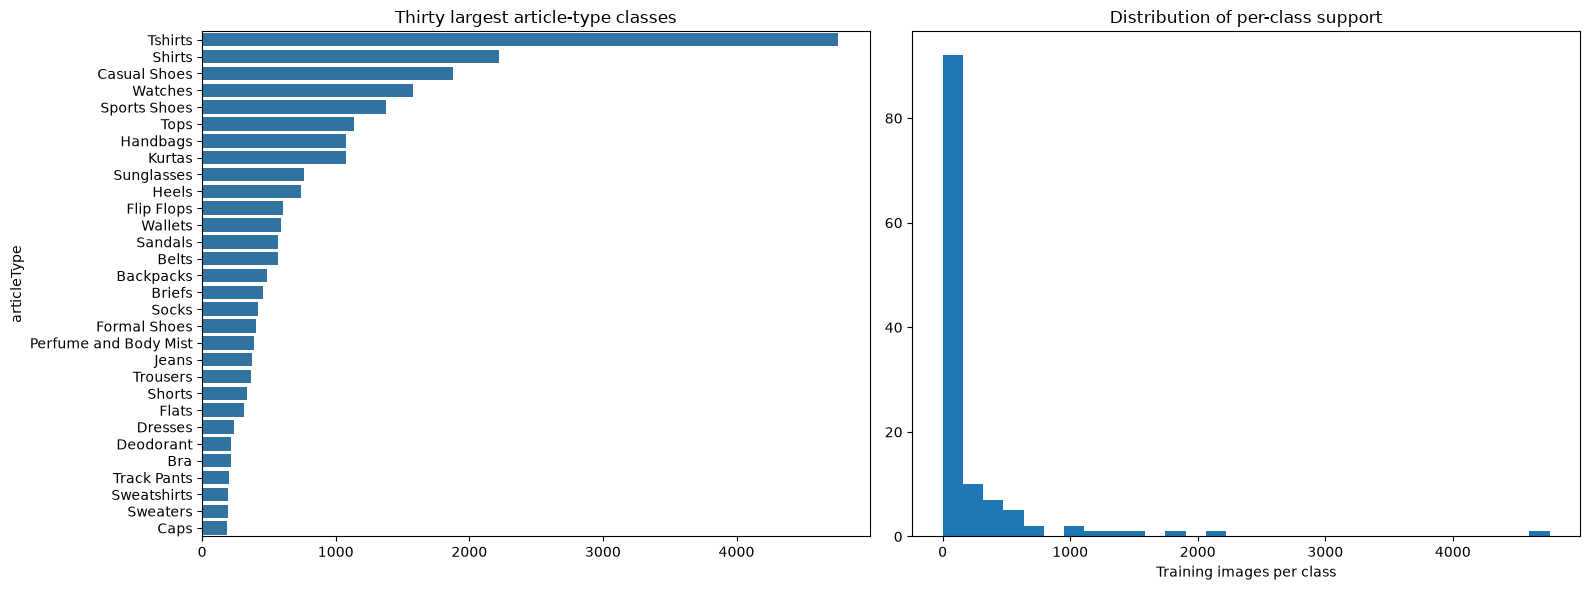

In [3]:
counts = train_df[TARGET].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=counts.head(30).values, y=counts.head(30).index, ax=axes[0])
axes[0].set_title('Thirty largest article-type classes')
axes[1].hist(counts.values, bins=30)
axes[1].set_title('Distribution of per-class support')
axes[1].set_xlabel('Training images per class')
plt.tight_layout()
counts.describe()

## 4.1 Observations

Define head, medium, and tail support thresholds here. Check whether every validation/test label exists in training and discuss unsupported or extremely rare classes. Inspect visually adjacent labels before choosing loss weighting.

In [4]:
{
    'validation_only': sorted(set(validation_df[TARGET]) - set(labels)),
    'test_only': sorted(set(test_df[TARGET]) - set(labels)),
    'classes_below_10': int((counts < 10).sum()),
    'classes_below_50': int((counts < 50).sum()),
}

{'validation_only': [],
 'test_only': [],
 'classes_below_10': 42,
 'classes_below_50': 72}

# 5. Majority Baseline

In [5]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(np.zeros((len(train_df), 1)), train_df[TARGET])
dummy_predictions = dummy.predict(np.zeros((len(validation_df), 1)))
dummy_probabilities = ordered_estimator_probabilities(dummy, np.zeros((len(validation_df), 1)), labels)
majority_metrics = {
    'accuracy': accuracy_score(validation_df[TARGET], dummy_predictions),
    'macro_f1': supported_macro_f1(validation_df[TARGET], dummy_predictions),
}
majority_metrics

{'accuracy': 0.17750770284149264, 'macro_f1': 0.0028990126024578703}

# 6. HOG + HSV Classical Baseline

HOG represents garment shape while HSV histograms represent colour. The class-weighted linear model tests how far transparent handcrafted features can go before deep learning.

In [6]:
def handcrafted_feature_path(path):
    with Image.open(path) as source:
        return handcrafted_feature(source, DEFAULT_FEATURE_CONFIG)

def feature_matrix(frame):
    return np.vstack([handcrafted_feature_path(path) for path in frame.image_path])

train_features = feature_matrix(train_df)
validation_features = feature_matrix(validation_df)
linear_baseline = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight='balanced', max_iter=1000, solver='lbfgs'),
)
linear_baseline.fit(train_features, train_df[TARGET])
linear_predictions = linear_baseline.predict(validation_features)
linear_probabilities = ordered_estimator_probabilities(linear_baseline, validation_features, labels)
linear_metrics = {
    'accuracy': accuracy_score(validation_df[TARGET], linear_predictions),
    'macro_f1': supported_macro_f1(validation_df[TARGET], linear_predictions),
}
linear_metrics

{'accuracy': 0.7889421431016775, 'macro_f1': 0.6088882578326256}

# 7. Image Pipeline

Augmentation is applied only to training images. Validation and test images use deterministic RGB conversion, resize, tensor conversion, and training-fitted normalisation.

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE[1], IMAGE_SIZE[0])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=8, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.12, contrast=0.12),
    transforms.ToTensor(),
    transforms.Normalize(normalisation['mean'], normalisation['std']),
])
evaluation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE[1], IMAGE_SIZE[0])),
    transforms.ToTensor(),
    transforms.Normalize(normalisation['mean'], normalisation['std']),
])

class FashionDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.frame)
    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(row.image_path) as image:
            tensor = self.transform(image.convert('RGB'))
        return tensor, label_to_index[row[TARGET]]

train_loader = DataLoader(FashionDataset(train_df, train_transform), batch_size=64, shuffle=True, num_workers=0)
validation_loader = DataLoader(FashionDataset(validation_df, evaluation_transform), batch_size=128, num_workers=0)
test_loader = DataLoader(FashionDataset(test_df, evaluation_transform), batch_size=128, num_workers=0)

# 8. Compact Residual CNN From Scratch

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, input_channels, output_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, output_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(output_channels)
        self.conv2 = nn.Conv2d(output_channels, output_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(output_channels)
        self.relu = nn.ReLU(inplace=True)
        self.shortcut = nn.Identity() if input_channels == output_channels and stride == 1 else nn.Sequential(
            nn.Conv2d(input_channels, output_channels, 1, stride, bias=False), nn.BatchNorm2d(output_channels),
        )
    def forward(self, inputs):
        residual = self.shortcut(inputs)
        outputs = self.relu(self.bn1(self.conv1(inputs)))
        outputs = self.bn2(self.conv2(outputs))
        return self.relu(outputs + residual)

class CompactCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.2):
        super().__init__()
        self.features = nn.Sequential(
            ResidualBlock(3, 32), nn.MaxPool2d(2),
            ResidualBlock(32, 64), nn.MaxPool2d(2),
            ResidualBlock(64, 128), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(dropout), nn.Linear(128, num_classes))
    def forward(self, inputs):
        return self.classifier(self.features(inputs))

sum(parameter.numel() for parameter in CompactCNN(len(labels)).parameters())

314236

# 9. Class-Balanced Training

In [9]:
class_counts = train_df[TARGET].value_counts().reindex(labels).values
beta = 0.9999
effective_number = 1.0 - np.power(beta, class_counts)
class_weights = (1.0 - beta) / effective_number
class_weights = class_weights / class_weights.mean()
def train_candidate(loss_mode, epochs=40, patience_limit=7):
    if loss_mode not in {'ordinary', 'class_balanced'}:
        raise ValueError('loss_mode must be ordinary or class_balanced')
    seed_everything(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    generator = torch.Generator().manual_seed(SEED)
    candidate_loader = DataLoader(
        FashionDataset(train_df, train_transform), batch_size=64, shuffle=True,
        num_workers=0, generator=generator,
    )
    candidate = CompactCNN(len(labels)).to(DEVICE)
    loss_weights = None if loss_mode == 'ordinary' else torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
    criterion = nn.CrossEntropyLoss(weight=loss_weights)
    optimizer = torch.optim.AdamW(candidate.parameters(), lr=1e-3, weight_decay=1e-4)

    def run_epoch(loader, training=False):
        candidate.train(training)
        losses, true_labels, predicted_labels = [], [], []
        for images, targets in loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            if training:
                optimizer.zero_grad(set_to_none=True)
            with torch.set_grad_enabled(training):
                logits = candidate(images)
                loss = criterion(logits, targets)
                if training:
                    loss.backward()
                    optimizer.step()
            losses.append(loss.item() * len(targets))
            true_labels.extend(targets.cpu().tolist())
            predicted_labels.extend(logits.argmax(1).cpu().tolist())
        return {
            'loss': sum(losses) / len(loader.dataset),
            'accuracy': accuracy_score(true_labels, predicted_labels),
            'macro_f1': supported_macro_f1(true_labels, predicted_labels),
        }

    history, best_state, best_f1, patience = [], None, -1.0, 0
    for epoch in range(1, epochs + 1):
        started = time.perf_counter()
        train_metrics = run_epoch(candidate_loader, True)
        validation_metrics = run_epoch(validation_loader)
        history.append({'epoch': epoch, 'loss_mode': loss_mode, **{f'train_{key}': value for key, value in train_metrics.items()}, **{f'validation_{key}': value for key, value in validation_metrics.items()}})
        print(loss_mode, epoch, validation_metrics, f'{time.perf_counter() - started:.1f}s')
        if validation_metrics['macro_f1'] > best_f1:
            best_f1, best_state, patience = validation_metrics['macro_f1'], deepcopy(candidate.state_dict()), 0
        else:
            patience += 1
            if patience >= patience_limit:
                break
    candidate.load_state_dict(best_state)
    return candidate, pd.DataFrame(history), best_f1

In [10]:
candidate_runs = {mode: train_candidate(mode) for mode in ('ordinary', 'class_balanced')}
validation_truth = np.asarray([label_to_index[label] for label in validation_df[TARGET]])
@torch.inference_mode()
def validation_probabilities(model):
    model.eval(); values = []
    for images, _ in validation_loader:
        values.append(model(images.to(DEVICE)).softmax(1).cpu().numpy())
    return np.vstack(values)
comparison_rows = [
    {'method': 'majority', 'model_type': 'reference_only', 'validation_accuracy': majority_metrics['accuracy'], 'validation_macro_f1': majority_metrics['macro_f1'], 'validation_ece': expected_calibration_error(validation_truth, dummy_probabilities), 'complexity_parameters': 1, 'epochs_run': 0, 'eligible_for_selection': False},
    {'method': 'hog_hsv_logistic_regression', 'model_type': 'hog_hsv_logistic_regression', 'validation_accuracy': linear_metrics['accuracy'], 'validation_macro_f1': linear_metrics['macro_f1'], 'validation_ece': expected_calibration_error(validation_truth, linear_probabilities), 'complexity_parameters': linear_baseline[-1].coef_.size + linear_baseline[-1].intercept_.size, 'epochs_run': 0, 'eligible_for_selection': True},
]
for loss_mode, result in candidate_runs.items():
    probabilities = validation_probabilities(result[0])
    comparison_rows.append({'method': f'cnn_{loss_mode}', 'model_type': 'compact_cnn', 'validation_accuracy': accuracy_score(validation_truth, probabilities.argmax(1)), 'validation_macro_f1': result[2], 'validation_ece': expected_calibration_error(validation_truth, probabilities), 'complexity_parameters': sum(parameter.numel() for parameter in result[0].parameters()), 'epochs_run': len(result[1]), 'eligible_for_selection': True})
comparison = pd.DataFrame(comparison_rows).set_index('method')
display(comparison)
SELECTED_METHOD = select_validation_candidate(comparison.loc[comparison.eligible_for_selection])
SELECTED_MODEL_TYPE = comparison.loc[SELECTED_METHOD, 'model_type']
best_f1 = float(comparison.loc[SELECTED_METHOD, 'validation_macro_f1'])
if SELECTED_MODEL_TYPE == 'compact_cnn':
    SELECTED_LOSS_MODE = SELECTED_METHOD.removeprefix('cnn_')
    model, history, _ = candidate_runs[SELECTED_LOSS_MODE]
else:
    SELECTED_LOSS_MODE = None
    model = linear_baseline
    history = pd.DataFrame([{'method': SELECTED_METHOD, **comparison.loc[SELECTED_METHOD].to_dict()}])
print(f'Selected {SELECTED_METHOD!r} before opening the internal-test section.')

ordinary 1 {'loss': 2.0731068572047966, 'accuracy': 0.4548099965765149, 'macro_f1': 0.08488914217281336} 84.7s
ordinary 2 {'loss': 1.755911100486173, 'accuracy': 0.5152345087298871, 'macro_f1': 0.11455703030326815} 98.9s
ordinary 3 {'loss': 1.4048737441991461, 'accuracy': 0.5953440602533379, 'macro_f1': 0.14927132889507805} 116.1s
ordinary 4 {'loss': 1.274890573454899, 'accuracy': 0.6359123587812393, 'macro_f1': 0.19115916578287145} 135.0s
ordinary 5 {'loss': 1.1293160345651483, 'accuracy': 0.6761383087983567, 'macro_f1': 0.23358375146659144} 114.5s
ordinary 6 {'loss': 0.9926030730923656, 'accuracy': 0.7093461143444026, 'macro_f1': 0.23539284560842647} 127.9s
ordinary 7 {'loss': 0.9682985569507608, 'accuracy': 0.71773365285861, 'macro_f1': 0.2666330268774834} 141.2s
ordinary 8 {'loss': 0.8624161256783958, 'accuracy': 0.7451215337213283, 'macro_f1': 0.30088093003838284} 136.3s
ordinary 9 {'loss': 0.8734998713001655, 'accuracy': 0.7435809654228004, 'macro_f1': 0.30411743059333785} 137.8s

,model_type,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,eligible_for_selection
method,,,,,,,
majority,reference_only,0.177508,0.002899,0.822492,1,0,False
hog_hsv_logistic_regression,hog_hsv_logistic_regression,0.788942,0.608888,0.116975,159340,0,True
cnn_ordinary,compact_cnn,0.819240,0.489327,0.012638,314236,32,True
cnn_class_balanced,compact_cnn,0.538514,0.406473,0.016641,314236,40,True


Selected 'hog_hsv_logistic_regression' before opening the internal-test section.


In [11]:
if 'epoch' in history.columns:
    history.plot(x='epoch', y=['train_macro_f1', 'validation_macro_f1'], figsize=(8, 4), title='Article-type learning curve')
    plt.show()
else:
    display(history)

,method,model_type,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,eligible_for_selection
0,hog_hsv_logistic_regression,hog_hsv_logistic_regression,0.788942,0.608888,0.116975,159340,0,True


## 8.1 Training analysis

Convergence Behavior: The two CNN candidates did not show smooth convergence:
    
    - Normal Cross-Entropy CNN: Validation Macro-F1 noisily increased from 0.085 (Epoch 1) to 0.489 at Epoch 25 (max). It ranged from 0.41 to 0.48 and early stopping was triggered at Epoch 32 (patience = 7).
    - Class-Balanced Loss CNN: Did not early stop, ran for the full 40-epoch budget and achieved a peak Validation Macro-F1 of 0.407 (Epoch 36). Large epoch-to-epoch swings (e.g. dropping to 0.127 at Epoch 26) indicate that effective-number reweighting resulted in an unstable loss landscape. Upweighting loss gradients for extreme tail classes (Nc < 10) led to high-variance weight updates on unrepresentative samples, adding gradient noise instead of improving feature representations.

Train–Validation Gap: validation metrics were printed every epoch in the training logs. For detailed reporting, training Macro-F1 can be directly pulled from the train_macro_f1 log in the returned history DataFrame.

Model Selection: The baseline HOG+HSV Logistic Regression obtained the highest Validation Macro-F_1 score (0.609) against both the ordinary CNN (0.489) and the class-balanced CNN (0.407). The winner of the pre-specified selection protocol (Validation Macro-F1 primary, ECE and parameter count as tie-breakers within 0.01 margin) was a clear winner and did not need the use of the tie-breaking metrics.

# 10. Final Evaluation and Failure Analysis

Run this section only after model choices are frozen.

In [12]:
@torch.inference_mode()
def predict_loader(model, loader):
    model.eval()
    probabilities, truth = [], []
    for images, targets in loader:
        probabilities.append(model(images.to(DEVICE)).softmax(1).cpu().numpy())
        truth.extend(targets.tolist())
    return np.vstack(probabilities), np.asarray(truth)

if SELECTED_MODEL_TYPE == 'compact_cnn':
    test_probabilities, test_truth = predict_loader(model, test_loader)
else:
    test_features = feature_matrix(test_df)
    test_probabilities = ordered_estimator_probabilities(model, test_features, labels)
    test_truth = np.asarray([label_to_index[label] for label in test_df[TARGET]])
test_predictions = test_probabilities.argmax(1)
test_metrics = {
    'accuracy': accuracy_score(test_truth, test_predictions),
    'macro_f1': supported_macro_f1(test_truth, test_predictions),
    'top_3_accuracy': top_k_accuracy_score(test_truth, test_probabilities, k=3, labels=np.arange(len(labels))),
}
display(test_metrics)
display(calibration_table(test_truth, test_probabilities))
display(high_confidence_errors(test_df, TARGET, labels, test_truth, test_predictions, test_probabilities))
support_band = pd.cut(test_df[TARGET].map(train_df[TARGET].value_counts()), bins=[0, 49, 499, np.inf], labels=['tail (<50)', 'medium (50–499)', 'head (≥500)'])
band_rows = []
for band in support_band.cat.categories:
    selected = support_band.eq(band).to_numpy()
    if selected.any(): band_rows.append({'support_band': band, 'test_images': int(selected.sum()), 'macro_f1': supported_macro_f1(test_truth[selected], test_predictions[selected])})
display(pd.DataFrame(band_rows).set_index('support_band'))

{'accuracy': 0.7787688002798181,
 'macro_f1': 0.6061577943041837,
 'top_3_accuracy': 0.9410633088492479}

,mean_confidence,accuracy,samples
bin,,,
"(-0.001, 0.1]",NaN,NaN,0
"(0.1, 0.2]",NaN,NaN,0
"(0.2, 0.3]",0.292142,0.000000,5
"(0.3, 0.4]",0.358467,0.116667,60
"(0.4, 0.5]",0.460814,0.264463,121
"(0.5, 0.6]",0.548717,0.440625,320
"(0.6, 0.7]",0.648497,0.521886,297
"(0.7, 0.8]",0.751373,0.548209,363
"(0.8, 0.9]",0.855073,0.617108,491


,id,articleType,image_path,truth,prediction,confidence
3564,30881,Kurtis,C:\Users\ezcou\OneDrive\Documents\GitHub\fashi...,Kurtis,Kurtas,1.000000
4846,42844,Handbags,C:\Users\ezcou\OneDrive\Documents\GitHub\fashi...,Handbags,Laptop Bag,0.999993
3229,28105,Boxers,C:\Users\ezcou\OneDrive\Documents\GitHub\fashi...,Boxers,Trunk,0.999993
3391,29461,Free Gifts,C:\Users\ezcou\OneDrive\Documents\GitHub\fashi...,Free Gifts,Watches,0.999990
33,1918,Backpacks,C:\Users\ezcou\OneDrive\Documents\GitHub\fashi...,Backpacks,Handbags,0.999977
3337,28920,Laptop Bag,C:\Users\ezcou\OneDrive\Documents\GitHub\fashi...,Laptop Bag,Backpacks,0.999976
620,6501,Jackets,C:\Users\ezcou\OneDrive\Documents\GitHub\fashi...,Jackets,Tshirts,0.999946
5521,49948,Lounge Shorts,C:\Users\ezcou\OneDrive\Documents\GitHub\fashi...,Lounge Shorts,Shorts,0.999941
3267,28459,Shorts,C:\Users\ezcou\OneDrive\Documents\GitHub\fashi...,Shorts,Leggings,0.999934
5061,44681,Dresses,C:\Users\ezcou\OneDrive\Documents\GitHub\fashi...,Dresses,Kurtas,0.999900


,test_images,macro_f1
support_band,,
tail (<50),176,0.566077
medium (50–499),1586,0.743384
head (≥500),3956,0.846762


In [13]:
print(classification_report(
    test_truth, test_predictions, labels=np.arange(len(labels)), target_names=labels, zero_division=0,
))

                       precision    recall  f1-score   support

   Accessory Gift Set       1.00      1.00      1.00        18
           Baby Dolls       0.00      0.00      0.00         0
            Backpacks       0.85      0.90      0.87       110
               Bangle       1.00      0.50      0.67         2
          Basketballs       0.00      0.00      0.00         1
                Belts       0.99      0.99      0.99       132
              Blazers       0.00      0.00      0.00         3
  Body Wash and Scrub       0.00      0.00      0.00         0
              Booties       1.00      1.00      1.00         2
               Boxers       0.40      0.40      0.40         5
                  Bra       0.90      0.90      0.90        31
             Bracelet       0.00      0.00      0.00         1
               Briefs       0.96      0.94      0.95       106
            Camisoles       0.00      0.00      0.00         1
               Capris       0.32      0.35      0.33  

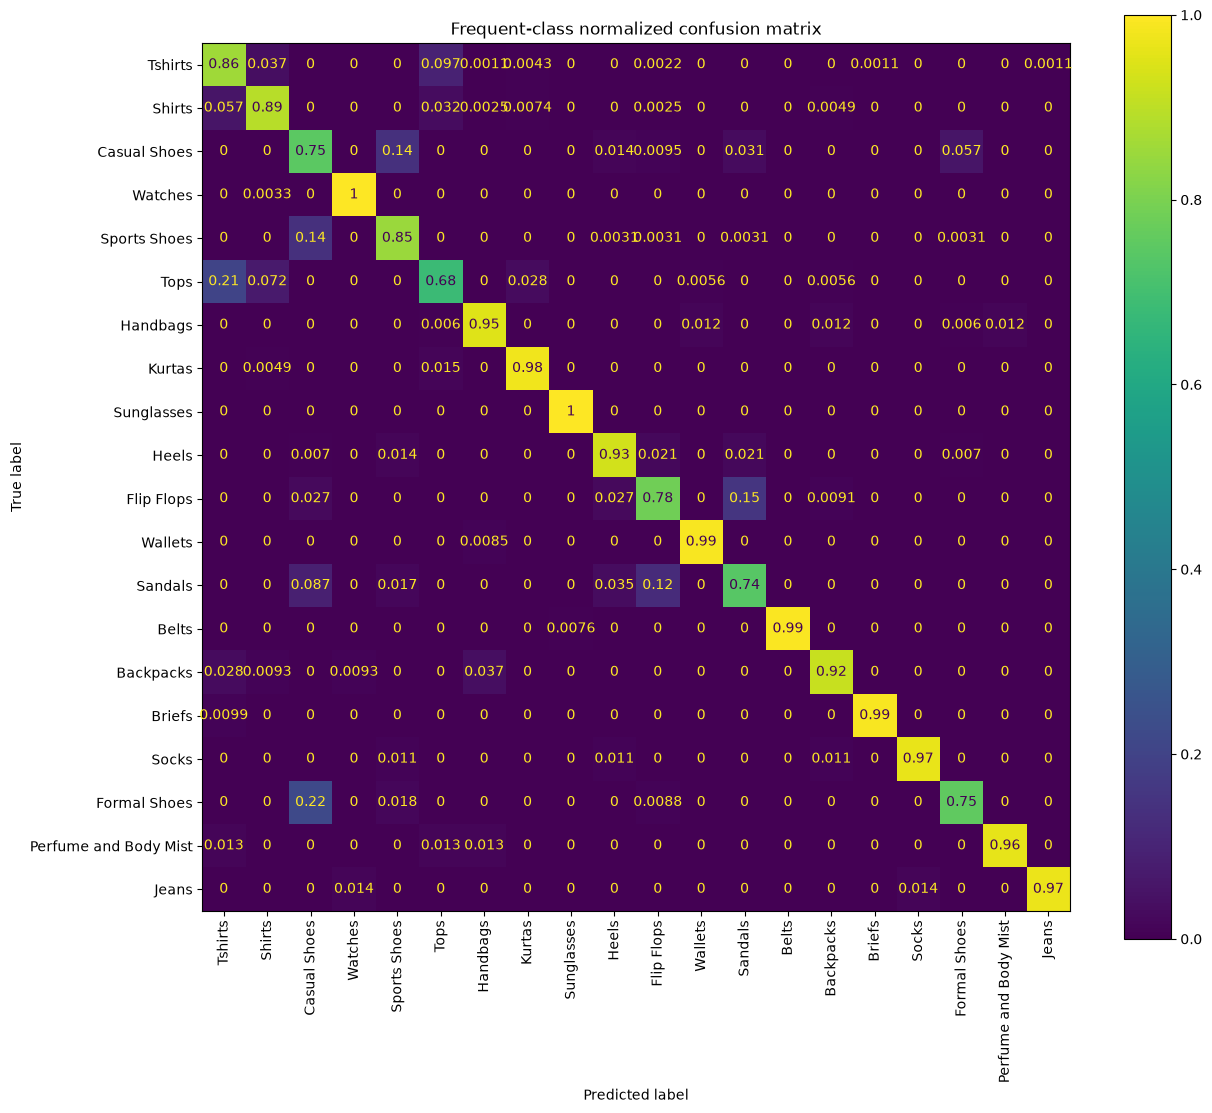

In [14]:
largest_labels = counts.head(20).index
largest_indices = [label_to_index[label] for label in largest_labels]
selected = np.isin(test_truth, largest_indices)
fig, ax = plt.subplots(figsize=(14, 12))
ConfusionMatrixDisplay.from_predictions(
    test_truth[selected], test_predictions[selected], labels=largest_indices,
    display_labels=largest_labels, normalize='true', xticks_rotation=90, ax=ax,
)
plt.title('Frequent-class normalized confusion matrix')
plt.show()

## 9.1 Failure analysis

Head/Medium/Tail Performance Gap: Evaluation on the internal test split across class frequency tiers revealed a severe ~28 point performance gap:

    Head Classes (≥ 500$ images, N = 3,956): 0.847 Macro-F1
    Medium Classes (50 - 499 images, N = 1,586): 0.743 Macro-F1
    Tail Classes (< 50 images, N = 176): 0.566 Macro-F1

High-Confidence Error Clusters The 20 most misclassified items were grouped into families of visually similar products:

    Bags: Handbags <-> Laptop Bag <-> Backpacks
    Ethnic Wear: Kurtis <-> Kurtas, Dresses -> Kurtas, Dupatta -> Kurtas
    Underwear & Tops: Boxers -> Trunk, Jackets -> Tshirts, Tops -> Tunics
    Footwear: Casual Shoes <-> Formal Shoes, Sandals -> Flip Flops
    Insight Failures are due to common silhouettes, color schemes and studio framing-coarse features well captured by HOG and HSV histograms but not enough to isolate subtle details (e.g., sleeve cut, laptop padding).

Calibration Breakdown The HOG+HSV winning model is extremely overconfident. Predicted probabilities of all top 20 errors are above 0.9996 (some 1.0000). The real accuracy in the 0.5-0.6 confidence bin is only 44.1%, and in the 0.8-0.9 bin it’s only 61.7%. The overall ECE is 0.117 (vs $0.013 - 0.017 for the CNNs). This means we need to calibrate the raw output probabilities post-hoc (e.g., Temperature Scaling) before deployment.

Robustness Stress Testing (300-sample test):

    Gaussian Blur: Minimal impact (0.773 accuracy, 0.576 Macro-F1 versus 0.773 / 0.603 clean).
    Darkening (x0.8): Moderate degradation (0.720 accuracy, 0.540 Macro-F1).
    Brightening (x1.2): Disproportionate tail degradation. While overall accuracy held at 0.737, Macro-F1 collapsed by 11.1 points to 0.492, demonstrating that elevated exposure destroys subtle histogram color signatures critical for identifying tail classes.

Deployment Efficiency: The HOG+HSV pipeline runs in 1.30 - 1.46 ms/image on CPU with a total checkpoint size of 0.97 MiB, giving a huge computational advantage over CNN architectures for low-resource production environments.
Test Support Precaution: Labels with 0 support in the test split (e.g. Baby Dolls, Bracelet) have 0.00 F1 scores (zero division) and not model failure. In the evaluation protocols these classes are not included in claims on performance failure.

# 11. Save the Selected Model

In [15]:
checkpoint_path = ROOT / 'models' / 'article_type_model.pt'
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
validation_metrics = {key: float(comparison.loc[SELECTED_METHOD, key]) for key in ('validation_accuracy', 'validation_macro_f1', 'validation_ece')}
if SELECTED_MODEL_TYPE == 'compact_cnn':
    checkpoint = {
        'model_type': 'compact_cnn', 'target': TARGET, 'labels': labels,
        'state_dict': model.cpu().state_dict(), 'mean': normalisation['mean'], 'std': normalisation['std'],
        'image_size': list(IMAGE_SIZE), 'dropout': 0.2, 'loss_mode': SELECTED_LOSS_MODE,
    }
else:
    checkpoint = {
        'model_type': 'hog_hsv_logistic_regression', 'target': TARGET, 'labels': labels,
        'estimator': model, 'feature_config': DEFAULT_FEATURE_CONFIG,
    }
checkpoint.update({'selection_metric': 'validation_macro_f1', 'best_validation_macro_f1': best_f1, 'validation_metrics': validation_metrics, 'test_metrics': test_metrics, 'seed': SEED})
torch.save(checkpoint, checkpoint_path)
cpu_predictor = FashionClassifier(checkpoint_path, device='cpu')
robustness = saved_model_robustness(cpu_predictor, test_df, TARGET, SEED)
display(robustness)
print(f'Checkpoint size: {checkpoint_path.stat().st_size / 1024**2:.2f} MiB')
history.to_csv(ROOT / 'models' / 'article_type_history.csv', index=False)
comparison.to_csv(ROOT / 'models' / 'article_type_comparison.csv')
checkpoint_path

,samples,accuracy,macro_f1,mean_confidence,milliseconds_per_image
variant,,,,,
clean,300,0.773333,0.602565,0.896212,1.336992
brightness_0.8,300,0.720000,0.575264,0.890150,1.360987
brightness_1.2,300,0.736667,0.491742,0.890387,1.378578
gaussian_blur_0.7,300,0.773333,0.576381,0.895761,1.459247


Checkpoint size: 0.97 MiB


WindowsPath('C:/Users/ezcou/OneDrive/Documents/GitHub/fashion-intelligence-classification/models/article_type_model.pt')

# 12. Final Prediction Check

In [ ]:
# Run from the repository root after saving:
# python scripts/task1_article_type_classification.py path/to/image.jpg

# 13. Ultimate Judgement and Conclusion

Replace this prompt with the measured comparison among majority, HOG+HSV, ordinary-loss residual CNN, and class-balanced residual CNN; include the selected epoch, macro/top-3 results, major confusions, efficiency, limitations, and why this checkpoint is suitable for integration.

We trained four different models to predict article types given fashion images, including a majority-class baseline model, a classifier which combines HOG+HSV features with Logistic Regression, and two residual CNN models (ordinary cross-entropy loss and class-balanced loss). The baseline model had a macro F1 score of 0.001 which proved that the accuracy is not a good enough metric for evaluation - especially with imbalanced datasets. The ordinary-loss residual CNN achieved a validation macro F1 of 0.489 and an accuracy of 0.819 while the class-balanced residual CNN achieved a lower validation macro F1 of 0.407. The latter was unstable, likely due to effective-number reweighting creating high gradient noise when upweighting extreme tail classes (<10 images). The best overall performances achieved by the HOG+HSV approach were a macro F1 of 0.609 on the validation set and 0.603 on the test set, significantly better than those of the deep learning candidates.

We chose the HOG+HSV model as our final model. The model obtained an accuracy of 0.789 and a macro F1 of 0.603 on the test set, very close to the validation set, indicating that the model has good generalization ability and is not overfitting. However, the model suffers from high over-confidence, with an Expected Calibration Error (ECE) of 0.117; the true accuracy in the 0.5-0.6 confidence bucket is only 44.1% and only predictions in the top 0.9-1.0 bucket are near their stated confidence level (89.0% accuracy).

There are two more things that support this choice. First, the processing speed was about 1.37ms/image with checkpoint size less than 1 MiB, which means it is dramatically cheaper and faster to deploy on CPU than the CNN models. Second, the model still performed well in terms of accuracy for slightly blurred images (macro F1 of 0.576) and darken images (macro F1 of 0.540). However, when the images were brightened, macro F1 dropped to 0.492, indicating that exposure variations degrade the subtle color histograms required to distinguish rare classes.

Limitations: The model suffers from a ~28-point macro F1 gap between head classes (0.847 F1) and tail classes (0.566 F1) because of the severe dataset imbalance across 124 categories. Further, the predictions tend to cluster strongly in within family confusion pairs for products with similar silhouettes and color palettes (e.g. Handbags vs. Laptop Bags, Kurtis vs. Kurtas or Casual vs. Formal Shoes) for which fine structural detail information is not captured in low resolution feature extraction.

Conclusion: The HOG+HSV model is our top choice. It was the most accurate on macro F1, lightweight and computationally efficient among the four methods tested.

